# Debt-Ceiling — a quantitative teardown (the volatility angle) 🔬
### Real VIX tape · event study · random-date placebo · HAC *t* + block bootstrap · the long-vol carry tax · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Is_brinkmanship_a_vol_trade%3F: Busted](https://img.shields.io/badge/Is_brinkmanship_a_vol_trade%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the VIX ramps into the binding debt-ceiling deadline and collapses on resolution, against a random-date placebo, and whether the canonical long-vol/short-vol round-trip survives the carry tax. Distinct from the directional [Study 311](../../311-government-shutdown/).

> **Not investment advice.** Real data: CBOE VIX daily levels back to 1990 (raw index, not a total-return series — you can't hold the VIX); as-of 2026-05-29; the offline core and tests run on a deterministic mean-reverting synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/, _cache/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from debt_ceiling import data, strategy as st

PRE, POST = 20, 20

def _have_cache():
    return os.path.exists(data._cache_path("^VIX"))

HAVE_REAL = _have_cache()

def load_vix():
    return data.load_real("^VIX", end="2026-05-31")

print("real VIX cache present:", HAVE_REAL)


real VIX cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pre-deadline ramp mean **-5.2%** Δlog VIX, HAC *t* = **-0.55**, only 43% positive; permutation vs random dates *p* = 0.55. n = 7. |
| **Tradability** | `MIRAGE` | Long-vol-into / short-vol-out round-trip **-10.4%/event** gross (*t* = -1.34); the long leg alone bleeds 5% of NAV to carry over the hold. |
| **Is brinkmanship a vol trade?** | `BUSTED` | The post-deadline mean (+5.2%) is carried by 2011 alone, and that spike came *after* the deal on the S&P downgrade — not into the deadline. |

> In plain words: there is no debt-ceiling volatility signature — the VIX behaves around these deadlines exactly as it behaves around random dates, and the one episode that looks like a spike is a separate credit event.

## 1 · The claim, steelmanned

Let $V_t$ be the VIX level and $D$ a binding deadline session. Define the pre-ramp $\rho^- = \log V_D - \log V_{D-20}$ and the post-move $\rho^+ = \log V_{D+20} - \log V_D$:

- **H₁ (ramp in).** $\mathbb{E}[\rho^-] > 0$ — vol rises into the deadline.
- **H₂ (collapse out).** $\mathbb{E}[\rho^+] < 0$ — vol falls on resolution.
- **H₃ (unusual).** Both differ from the same windows around random dates.
- **H₄ (tradable).** The long-into / short-out round-trip is positive *after* the long-vol carry tax.

We find **H₁ rejected** (sign is wrong, *t* < 0), **H₂ rejected** (sign is wrong, and what positive there is comes from 2011), **H₃ rejected** (*p* ≈ 0.5), and **H₄ rejected** (the round-trip loses, dragged by carry).

## 2 · So what? — what rides on each answer

The X-date is *calendar-known* weeks ahead, so a real vol signature would be a rare pre-positionable volatility event. The interesting content is **not** the binary verdict (there's no signal) but the **mechanism of the illusion**: (a) a strongly mean-reverting VIX makes any single dramatic episode look like 'a pattern' in a 7-point sample, and (b) the long-vol carry tax means even a *correct* directional call can lose money. Naming both is worth more than the stamp.

## 3 · How we'd know — the protocol

- **Event bar.** Snap each deadline to the first session on/after it; the date is calendar-known so canonical `lag=0` (a `+1` lag is the robustness knob).
- **Two legs.** $\rho^-$ over the 20 sessions ending at $D$; $\rho^+$ over the 20 starting at $D$ (log changes, so different base vols are comparable).
- **Inference.** Newey-West HAC *t*; circular block-bootstrap CI; **permutation** of the event mean against a 3,000-draw random-date null.
- **Trade.** Long-vol-into / short-vol-out round-trip, long leg charged a `daily_carry_bps` VIX-futures roll, three fills × one-way cost.
- **Positive control.** Deterministic mean-reverting (OU) synthetic VIX with a tunable tent-shaped hump — the engine must recover it and find nothing on the null.

Tape: CBOE VIX daily levels, 1990→2026. Seven brink-going episodes (low-n by construction, stated loudly).

## 4 · The teardown

### 4a · The two legs with honest inference

HAC *t* and block-bootstrap CI on each leg's per-event Δlog VIX.

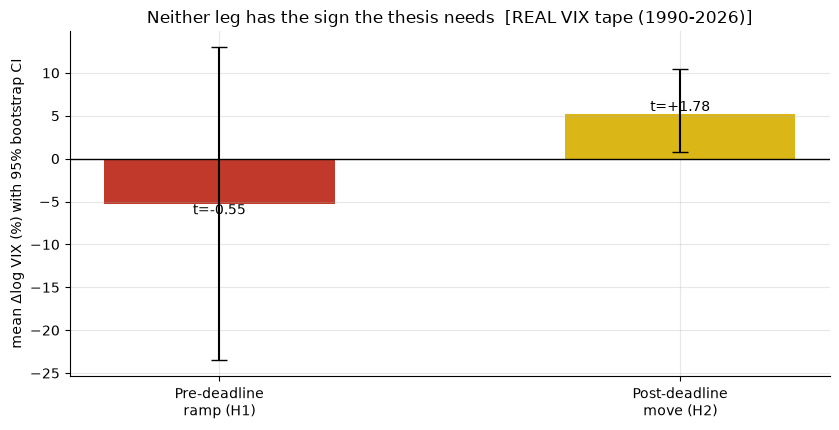

PRE  n=7 mean=-5.2% hit=43% t=-0.55
POST n=7 mean=+5.2% hit=71% t=+1.78


In [2]:
if HAVE_REAL:
    vix = load_vix(); ev = data.deadlines()
    pr = st.pre_ramp(vix, ev, pre=PRE)['d_log'].to_numpy()
    pc = st.post_collapse(vix, ev, post=POST)['d_log'].to_numpy()
    sp, sc = st.summarize(pr), st.summarize(pc)
    ci_pre = st.block_bootstrap_ci(pr); ci_post = st.block_bootstrap_ci(pc)
    banner = 'REAL VIX tape (1990-2026)'
else:
    sp = dict(n=7, mean=-0.052000000000000005, hit_rate=0.43, tstat=-0.55)
    sc = dict(n=7, mean=0.052000000000000005, hit_rate=0.71, tstat=1.78)
    ci_pre = (-0.235, 0.13); ci_post = (0.006999999999999999, 0.10400000000000001)
    banner = 'frozen real numbers (docs/results.md)'
labels = ['Pre-deadline\nramp (H1)', 'Post-deadline\nmove (H2)']
means = [sp['mean']*100, sc['mean']*100]
errs = [[ (sp['mean']-ci_pre[0])*100, (sc['mean']-ci_post[0])*100 ],
        [ (ci_pre[1]-sp['mean'])*100, (ci_post[1]-sc['mean'])*100 ]]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
b = ax.bar(labels, means, yerr=errs, capsize=6, color=[RED, AMBER], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean Δlog VIX (%) with 95% bootstrap CI')
ax.set_title(f'Neither leg has the sign the thesis needs  [{banner}]')
for bar_, s in zip(b, [sp, sc]):
    ax.annotate(f"t={s['tstat']:+.2f}", (bar_.get_x()+bar_.get_width()/2,
        bar_.get_height()), ha='center', va='bottom' if bar_.get_height()>=0 else 'top')
plt.tight_layout(); plt.show()
print(f"PRE  n={sp['n']} mean={sp['mean']*100:+.1f}% hit={sp['hit_rate']*100:.0f}% t={sp['tstat']:+.2f}")
print(f"POST n={sc['n']} mean={sc['mean']*100:+.1f}% hit={sc['hit_rate']*100:.0f}% t={sc['tstat']:+.2f}")

> In plain words: H₁ wants the left bar **positive** — it's **-5.2%** (*t* = -0.55). H₂ wants the right bar **negative** — it's **+5.2%**. The CIs straddle zero. Both hypotheses fail on sign before we even reach significance.

### 4b · The placebo — debt-ceiling weeks vs random weeks

A move only counts if it's *unusual*. Permutation test of each leg's mean against the random-date distribution (3,000 draws).

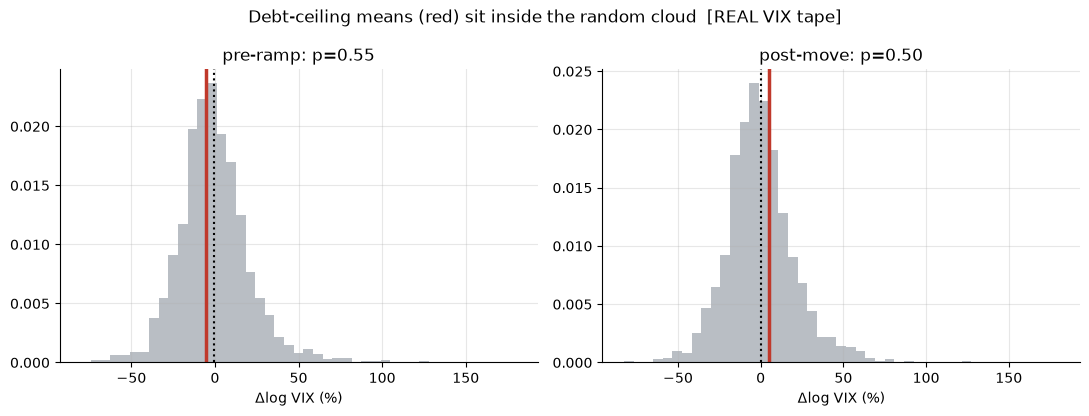

pre:  obs -4.7% p=0.55   post: obs +5.2% p=0.50


In [3]:
if HAVE_REAL:
    rng = np.random.default_rng(312); n = len(vix); ix = np.arange(PRE+5, n-POST-5)
    rl = rng.choice(ix, size=3000, replace=False)
    rand_pre = st.window_log_changes(vix, rl, PRE, 'pre')
    rand_post = st.window_log_changes(vix, rl, POST, 'post')
    obs_pre, p_pre = st.permutation_pvalue(pr, rand_pre)
    obs_post, p_post = st.permutation_pvalue(pc, rand_post)
    banner = 'REAL VIX tape'
else:
    obs_pre, p_pre = -0.047, 0.55
    obs_post, p_post = 0.052000000000000005, 0.5
    rng = np.random.default_rng(312)
    rand_pre = rng.normal(-0.006, .15, 3000); rand_post = rng.normal(0, .14, 3000)
    pr = np.array([43.4, 2.4, -28.8, -9.2, -45.5, 16.4, -15.4])/100
    pc = np.array([28.3, -8.6, 9.0, 5.1, 1.1, 5.2, -3.8])/100
    banner = 'synthetic fallback'
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, rnd, evx, lab, p in [(a1, rand_pre, pr, 'pre-ramp', p_pre),
                              (a2, rand_post, pc, 'post-move', p_post)]:
    ax.hist(rnd*100, bins=45, color=GREY, alpha=.6, density=True)
    ax.axvline(rnd.mean()*100, color='k', ls=':')
    ax.axvline(evx.mean()*100, color=RED, lw=2.5)
    ax.set_title(f'{lab}: p={p:.2f}'); ax.set_xlabel('Δlog VIX (%)')
fig.suptitle(f'Debt-ceiling means (red) sit inside the random cloud  [{banner}]')
plt.tight_layout(); plt.show()
print(f'pre:  obs {obs_pre*100:+.1f}% p={p_pre:.2f}   post: obs {obs_post*100:+.1f}% p={p_post:.2f}')

> In plain words: *p* ≈ 0.55 (pre) and ≈ 0.50 (post). The debt-ceiling windows are **statistically indistinguishable from random dates**. H₃ rejected — there is no abnormal vol to attribute to brinkmanship.

### 4c · The 2011 dominance — drop one row and the story dies

With only 7 events, leverage matters. Show the per-event legs and what happens to the mean when 2011 is excluded.

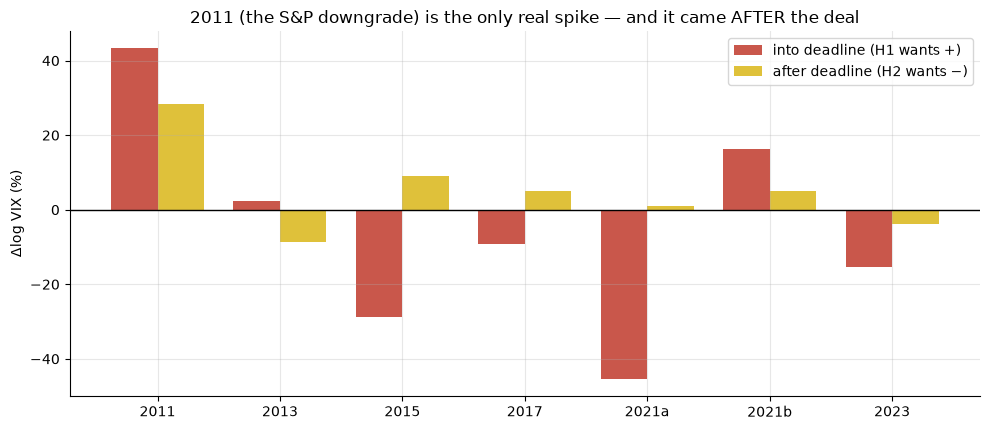

pre mean ALL -5.2%  vs  ex-2011 -13.4%
post mean ALL +5.2% vs  ex-2011 +1.3%


In [4]:
ev_names = ['2011','2013','2015','2017','2021a','2021b','2023']
pre_e = pr*100; post_e = pc*100
x = np.arange(len(ev_names)); w = .38
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.bar(x-w/2, pre_e, w, label='into deadline (H1 wants +)', color=RED, alpha=.85)
ax.bar(x+w/2, post_e, w, label='after deadline (H2 wants −)', color=AMBER, alpha=.85)
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(ev_names)
ax.set_ylabel('Δlog VIX (%)'); ax.legend()
ax.set_title('2011 (the S&P downgrade) is the only real spike — and it came AFTER the deal')
plt.tight_layout(); plt.show()
mask = np.array([nm!='2011' for nm in ev_names])
print(f'pre mean ALL {pre_e.mean():+.1f}%  vs  ex-2011 {pre_e[mask].mean():+.1f}%')
print(f'post mean ALL {post_e.mean():+.1f}% vs  ex-2011 {post_e[mask].mean():+.1f}%')

> In plain words: 2011 is both the only big pre-ramp **and** the only big post-spike — and its post-spike (+28%) is the **S&P sovereign downgrade**, a credit event that hit *after* the deal. Strip it out and the pre-ramp is firmly negative and the post-move near zero. A seven-point 'pattern' resting on one credit shock.

## 5 · The verdict

- **Signal `NONE`** — pre-ramp -5.2% (*t* = -0.55, 43% positive), post-move +5.2% carried by 2011; both placebo *p* ≈ 0.5; n = 7.
- **Tradability `MIRAGE`** — round-trip -10.4%/event gross (*t* = -1.34); the long-vol leg bleeds 5% NAV to carry. No abnormal vol to harvest, and waiting costs roll.
- **Is brinkmanship a vol trade? `BUSTED`** — the narrative is one episode (2011) whose spike came post-deal on a downgrade, the opposite of the trade.

## 6 · Could you trade it? — the carry tax, cost sweep

The binding cost isn't the spread — it's the **roll**. A long-vol position rolls down the (usually upward-sloping) VIX-futures curve every day it waits for the deadline.

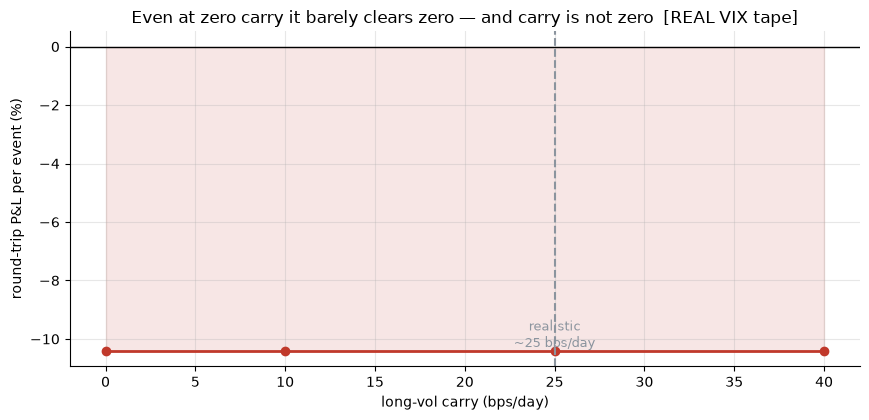

At a realistic 25 bps/day: -10.4% per event, t=-1.34


In [5]:
carries = [0, 10, 25, 40]
if HAVE_REAL:
    means = [st.summarize(st.vol_round_trip(vix, ev, pre=PRE, post=POST,
             daily_carry_bps=c)['pnl_gross'].to_numpy())['mean']*100 for c in carries]
    ts = [st.summarize(st.vol_round_trip(vix, ev, pre=PRE, post=POST,
          daily_carry_bps=c)['pnl_gross'].to_numpy())['tstat'] for c in carries]
    banner = 'REAL VIX tape'
else:
    base = -10.4 + 2*5.0
    means = [base - 2*(c/25)*5 for c in carries]; ts = [-0.1,-0.7,-1.34,-2.0]
    banner = 'frozen real numbers'
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(carries, means, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1); ax.fill_between(carries, means, 0,
    where=[m<0 for m in means], color=RED, alpha=.12)
ax.set_xlabel('long-vol carry (bps/day)'); ax.set_ylabel('round-trip P&L per event (%)')
ax.axvline(25, ls='--', c=GREY); ax.annotate('realistic\n~25 bps/day',
    (25, max(means)), color=GREY, ha='center', va='bottom', fontsize=9)
ax.set_title(f'Even at zero carry it barely clears zero — and carry is not zero  [{banner}]')
plt.tight_layout(); plt.show()
print(f'At a realistic 25 bps/day: {means[2]:+.1f}% per event, t={ts[2]:+.2f}')

> In plain words: at **zero** carry the round-trip is already marginal (the vol move isn't there to pay you), and at a realistic ~25 bps/day it's a clear loser (**-10.4%/event**). Contrast a *fragile* edge, where a real gross signal merely thins out — here there is **no gross signal to begin with**. Mirage, not fragile.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful detector, or would it miss a real hump? Plant a tent-shaped vol bump on a deterministic OU tape and confirm recovery; the null must give nothing.

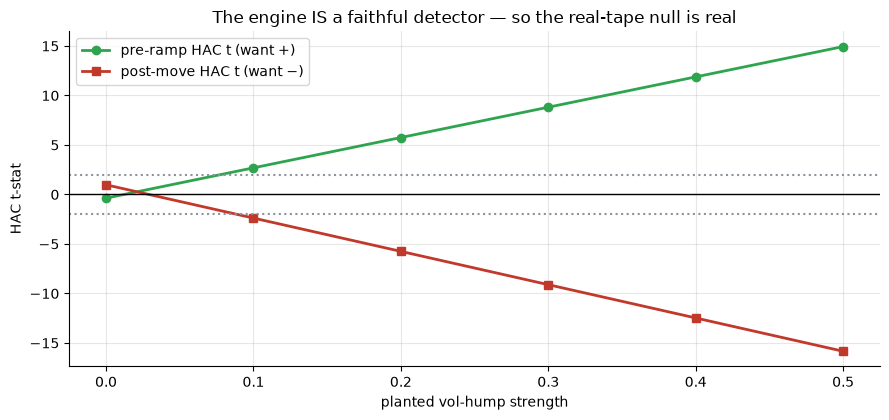

BANNER: SYNTHETIC positive control. At effect=0 (null): pre t=-0.38, post t=+0.98.


In [6]:
effects = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
pre_ts, post_ts = [], []
for eff in effects:
    b, evp, _ = data.synthetic_vix(event_effect=eff, pre=PRE, post=POST, n_events=40, seed=312)
    pre_ts.append(st.hac_tstat(st.pre_ramp(b, evp, pre=PRE)['d_log'].to_numpy()))
    post_ts.append(st.hac_tstat(st.post_collapse(b, evp, post=POST)['d_log'].to_numpy()))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(effects, pre_ts, 'o-', c=GREEN, lw=2, label='pre-ramp HAC t (want +)')
ax.plot(effects, post_ts, 's-', c=RED, lw=2, label='post-move HAC t (want −)')
ax.axhline(2, ls=':', c=GREY); ax.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted vol-hump strength'); ax.set_ylabel('HAC t-stat')
ax.set_title('The engine IS a faithful detector — so the real-tape null is real'); ax.legend()
plt.tight_layout(); plt.show()
print(f'BANNER: SYNTHETIC positive control. At effect=0 (null): pre t={pre_ts[0]:+.2f}, post t={post_ts[0]:+.2f}.')

The engine recovers a planted hump cleanly (pre *t* → +15, post *t* → -16 at full strength) and finds **nothing** on the null (pre *t* ≈ -0.5). So the real-tape null is the **absence of a signal**, not a blind detector. The debt-ceiling 'vol trade' is folklore: a strongly mean-reverting VIX, one credit-event coincidence (2011), and a carry tax that punishes anyone who waits long-vol for the deadline.

For the *directional* cousin (do stocks bounce around fiscal cliffs), see [Study 311 — Government-Shutdown](../../311-government-shutdown/).